In [1]:
import sys
import torch 
import os
import pickle

""" Run this cell before you run anything. This ensures the modular imports work correctly"""

working_root_directory="/teamspace/studios/this_studio/resnet18_cifar10_classifier"

if working_root_directory not in sys.path: 
    sys.path.append(working_root_directory)

In [2]:
from utils.helper_utils import (
    load_prepare_cifar10,
    build_transforms,
    load_resnet18
    )

from utils.visualization_utils import (
    load_and_plot_metrics_history,
    load_csv_main_model_metrics_history,
    extract_dataframe,
    confusion_matrix_plot,
    sample_image,
    each_class_accuracy,
    visualize_per_class_classification_report
    )

from src.test import load_model_for_test,test_model
from src.calibrate import calibrate_eval_model,visualize_reliability_diagram
from config.exp_config import dataset_dir,baseline_model_dir,csv_file_path
from torch.utils.data import DataLoader
from typing import List


In [3]:
#Device
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [4]:
def get_datasets(add_standard_augmentation:bool,add_random_erasing:bool):
        #download cifar10 dataset if it doesn't exist or it is corrupted
        train_dataset,val_dataset,test_dataset=load_prepare_cifar10(
                dataset_path=f"../{dataset_dir}", #notice i have chaged the dataset dir due to current script running jupyter notebook dir
                build_transforms=build_transforms,
                image_size=224,
                standard_aug=add_standard_augmentation,#set False not to be applied standard augmentation or True
                add_random_erasing=add_random_erasing
                )
        return train_dataset,val_dataset,test_dataset 

In [6]:
# def plot_consine_annealing_performance(
#     csv_file_dict:dict,
#     save_path: str|None=None
#     ):

#     """
#     Plots the learning rates across different layers over epochs.
    
#     Parameters:
#         csv_file_dict (dict): The dict for csv dict
#         save_path (str, optional): File path to save the generated plot.
#     """
#     plt.figure(figsize=(10, 6))
    
#     # Plot each learning rate series
#     plt.plot(range(1,csv_file_dict["epoch"]+1),csv_file_dict["fc_lr"], label='FC Layer LR')
#     plt.plot(range(1,csv_file_dict["epoch"]+1),csv_file_dict["layer3_lr"], label= 'Layer3 LR')
#     plt.plot(range(1,csv_file_dict["epoch"]+1),csv_file_dict["layer4_lr"], label='Layer 4 LR')
    
#     # Formatting the plot
#     plt.title('Cosine Annealing Performance', fontsize=14, fontweight='bold')
#     plt.xlabel('Epochs', fontsize=12)
#     plt.ylabel('Learning Rate', fontsize=12)
    
#     # Use scientific notation for small learning rates
#     plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#     plt.legend(fontsize=11, loc='upper right')
#     plt.tight_layout()
    
#     # Save or show the plot
#     if save_path:
#         plt.savefig(save_path, dpi=300)
#         print(f"Plot successfully saved to {save_path}")
#     else:
#         plt.show()



In [5]:
def get_test_history_dict(dict_path:str,experiment_name:str): 
    "load saved history dict"
    with open(os.path.join(f"{dict_path}/{experiment_name}","test_history.pkl"),"rb") as f: 
        pickle_history=pickle.load(f)
    return pickle_history

### Load clean dataset to train dataset

In [6]:
train_dataset,val_dataset,test_dataset=get_datasets(add_standard_augmentation=False,add_random_erasing=False)

downloaded cifar10 dataset ...


In [7]:
print(f"length of train dataset after splitting {len(train_dataset)}")
print(f"length of val dataset after splitting {len(val_dataset)}")
print(f"length of test dataset  {len(test_dataset)}")

#get the classes
cifar10_classes=train_dataset.subset.dataset.classes
cifar10_classes_len=len(cifar10_classes)
#num classes
print(cifar10_classes)
print(f"Len of classes {cifar10_classes_len}")

length of train dataset after splitting 40000
length of val dataset after splitting 10000
length of test dataset  10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Len of classes 10


In [8]:
test_loader = DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,          # no need to shuffle test set
        num_workers=4,
        pin_memory=True,        # speeds up transfer to GPU
        persistent_workers=True # keeps workers alive across epochs
    )

In [9]:
#call pretrained resnet18 and freezed backbone model
model=load_resnet18(device=device)
for name,param in model.named_parameters():
  print(f"{name}:{param.requires_grad}")

print(f"classification layer head {model.fc.out_features}")

conv1.weight:False
bn1.weight:False
bn1.bias:False
layer1.0.conv1.weight:False
layer1.0.bn1.weight:False
layer1.0.bn1.bias:False
layer1.0.conv2.weight:False
layer1.0.bn2.weight:False
layer1.0.bn2.bias:False
layer1.1.conv1.weight:False
layer1.1.bn1.weight:False
layer1.1.bn1.bias:False
layer1.1.conv2.weight:False
layer1.1.bn2.weight:False
layer1.1.bn2.bias:False
layer2.0.conv1.weight:False
layer2.0.bn1.weight:False
layer2.0.bn1.bias:False
layer2.0.conv2.weight:False
layer2.0.bn2.weight:False
layer2.0.bn2.bias:False
layer2.0.downsample.0.weight:False
layer2.0.downsample.1.weight:False
layer2.0.downsample.1.bias:False
layer2.1.conv1.weight:False
layer2.1.bn1.weight:False
layer2.1.bn1.bias:False
layer2.1.conv2.weight:False
layer2.1.bn2.weight:False
layer2.1.bn2.bias:False
layer3.0.conv1.weight:False
layer3.0.bn1.weight:False
layer3.0.bn1.bias:False
layer3.0.conv2.weight:False
layer3.0.bn2.weight:False
layer3.0.bn2.bias:False
layer3.0.downsample.0.weight:False
layer3.0.downsample.1.weight:Fa

test_set - True is  only for plotting the test dataset.


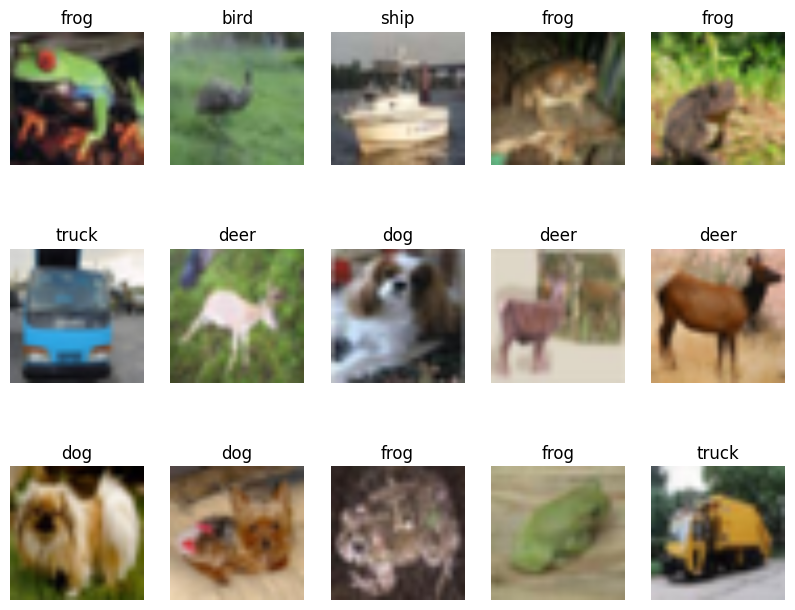

In [10]:
sample_image(train_dataset,test_set=False) #plot unnormalized 15 images

### Load dataset applied standard augmenation to train dataset

In [11]:
train_dataset2,val_dataset2,test_dataset2=get_datasets(add_standard_augmentation=True,add_random_erasing=False)

downloaded cifar10 dataset ...


test_set - True is  only for plotting the test dataset.


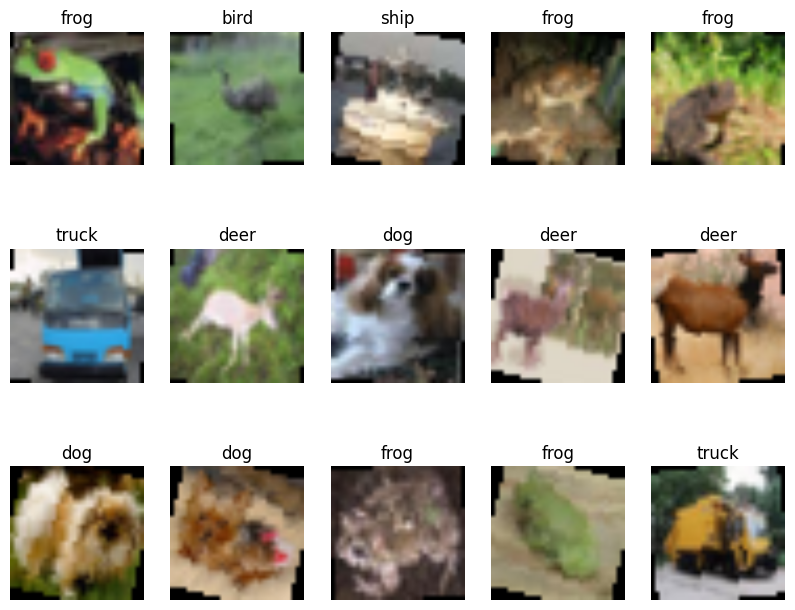

In [12]:
sample_image(train_dataset2,test_set=False) #plot unnormalized 15 images

### Load dataset applied random erasing to train dataset

In [13]:
train_dataset3,val_dataset3,test_dataset3=get_datasets(add_standard_augmentation=False,add_random_erasing=True)

downloaded cifar10 dataset ...


test_set - True is  only for plotting the test dataset.


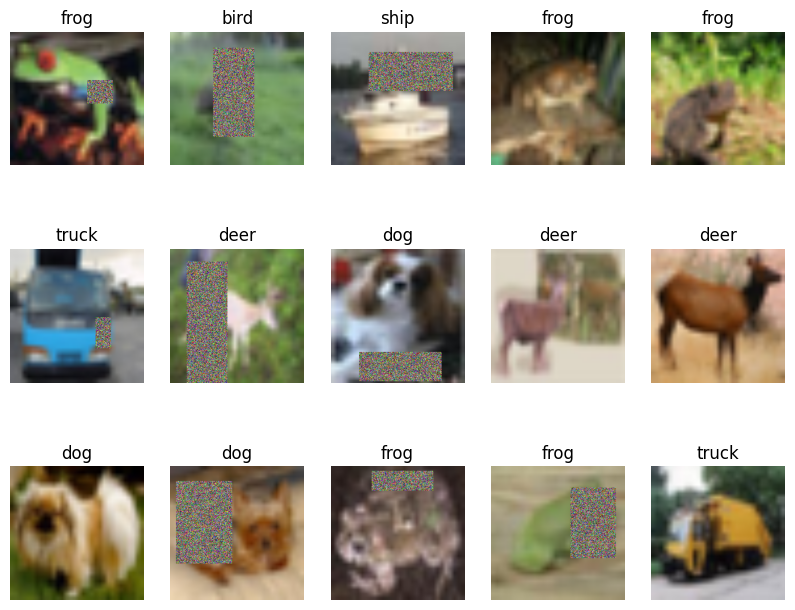

In [14]:
sample_image(train_dataset3,test_set=False) #plot unnormalized 15 images

# Baseline Model

## Baseline model plot for train accuracy/loss and val accuracy/loss to optimize the model performance

##### Note: when using "load_and_plot_metrics_history" for plotting the baseline metrics or main model metrics histories, note that baseline=True and baseline_path are only used for plotting baseline history. When setting baseline=True, don't forget to set the baseline_path too.

In [12]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=10,
    experiment_name="(only unfreezing fc layer) baseline",
    baseline=True,
    baseline_path=baseline_model_dir
)

baseline - True is only for baseline plots


KeyError: 'train_acc'

# Experiment 2
## CSV file for experiment 2 (baseline + unfreezing layer4 and fc)

In [ ]:
exp2_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp2")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp2/metrics_v1.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp2/metrics_v2.csv']


In [ ]:
#extract and preprare the csv experiment2 dataframe to dictionary for easier plotting 
experiment2_prepared_csv=extract_dataframe(df=exp2_csv)

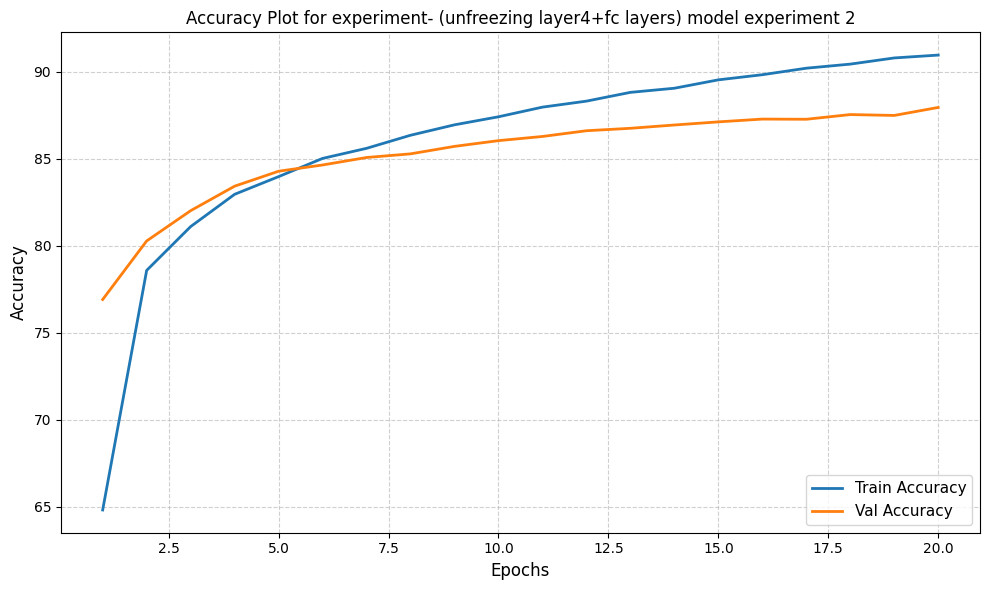

Accuracy plot has been plotted


Train Accuracy for (unfreezing layer4+fc layers) model experiment 2: 90.97
Val Accuracy for (unfreezing layer4+fc layers) model experiment 2: 87.96


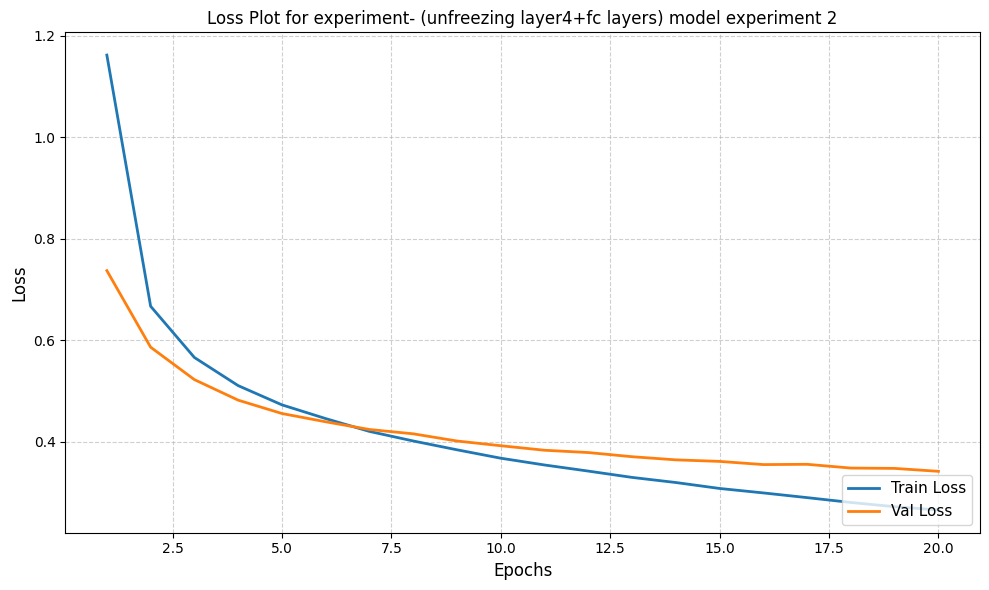

Loss plot has been plotted


Train Loss for (unfreezing layer4+fc layers) model experiment 2: 0.27
Val Loss for (unfreezing layer4+fc layers) model experiment 2: 0.34


In [ ]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment2_prepared_csv["epoch"],
    experiment_name="(unfreezing layer4+fc layers) model experiment 2",
    baseline=False,
    main_model_history=experiment2_prepared_csv
)

# Experiment 3 
## (Exp2+standard augmentation (RandomHorizonalFlip(p=0.5)+RandomRotation(degrees=15)))

In [ ]:
exp3_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp3")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp3/metrics3_V1.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp3/metrics3_V2.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp3/metrics3_V3.csv']


In [ ]:
#extract and preprare the csv experiment3 dataframe to dictionary for easier plotting 
experiment3_prepared_csv=extract_dataframe(df=exp3_csv)

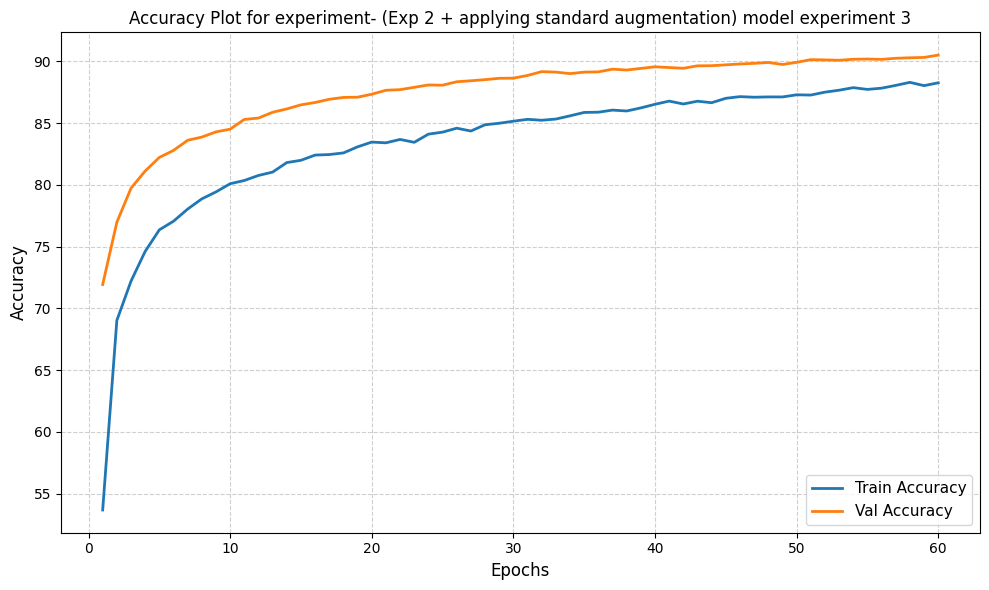

Accuracy plot has been plotted


Train Accuracy for (Exp 2 + applying standard augmentation) model experiment 3: 88.30
Val Accuracy for (Exp 2 + applying standard augmentation) model experiment 3: 90.51


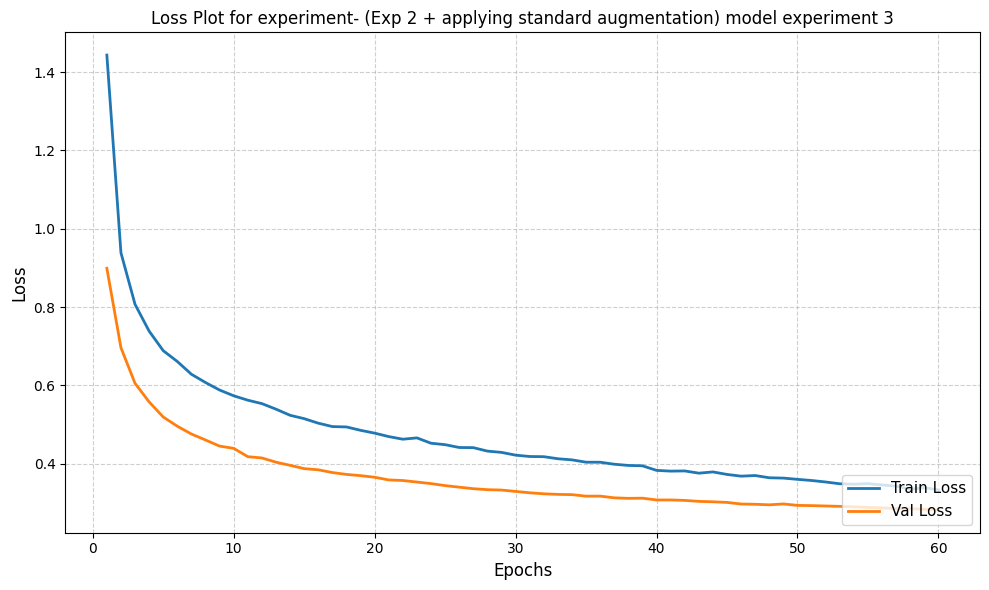

Loss plot has been plotted


Train Loss for (Exp 2 + applying standard augmentation) model experiment 3: 0.33
Val Loss for (Exp 2 + applying standard augmentation) model experiment 3: 0.28


In [ ]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment3_prepared_csv["epoch"],
    experiment_name="(Exp 2 + applying standard augmentation) model experiment 3",
    baseline=False,
    main_model_history=experiment3_prepared_csv
)

## Exp4 V1 --- Exp3 + Cosine Annealing (learning rates= (1e-4,1e-3), layers=(fc,layer4))

##### In Exp4 V1, I built on Exp3 but added cosine annealing while keeping the same learning rates. I trained for 60 epochs but early stopping cut it at 54. The model finished with train accuracy 85.55% and validation accuracy 88.66%. The results were decent, but the small learning rates probably held it back. Since cosine annealing steadily lowers the LR following the cosine curve, it hit the minimum too soon and the model didn’t get enough time at a stronger LR to push accuracy higher.

## Exp4 V2 - Exp3+Cosine Anealing (higher learning rates (3e-4,3e-3))

In [18]:
exp4_v2_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp4_v2")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp4_v2/metrics_exp4_v2.csv']


In [19]:
#extract and preprare the csv experiment4 version 2 dataframe to dictionary for easier plotting 
experiment4_v2_prepared_csv=extract_dataframe(df=exp4_v2_csv)

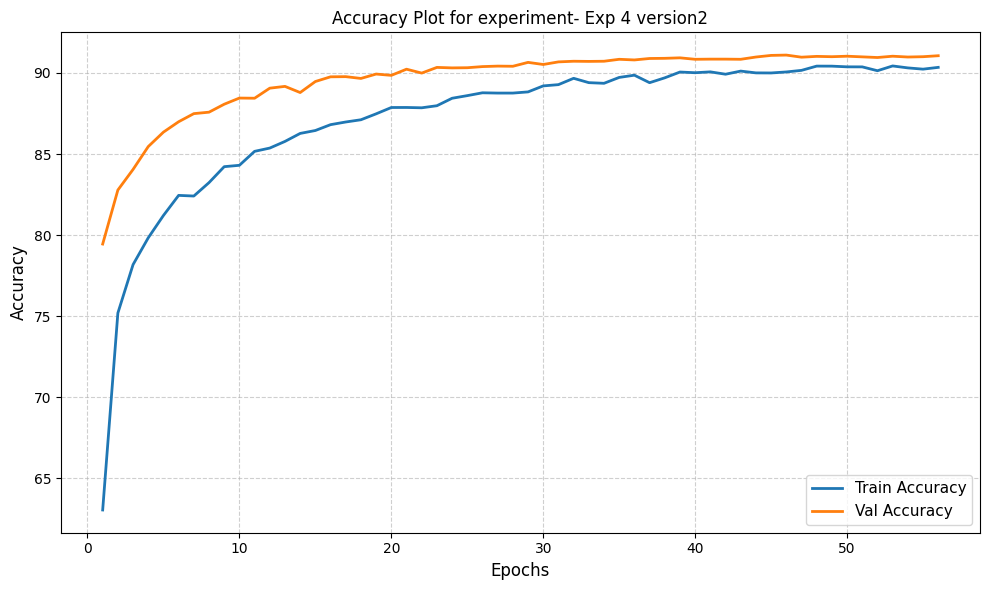

Accuracy plot has been plotted


Train Accuracy for Exp 4 version2: 90.43
Val Accuracy for Exp 4 version2: 91.10


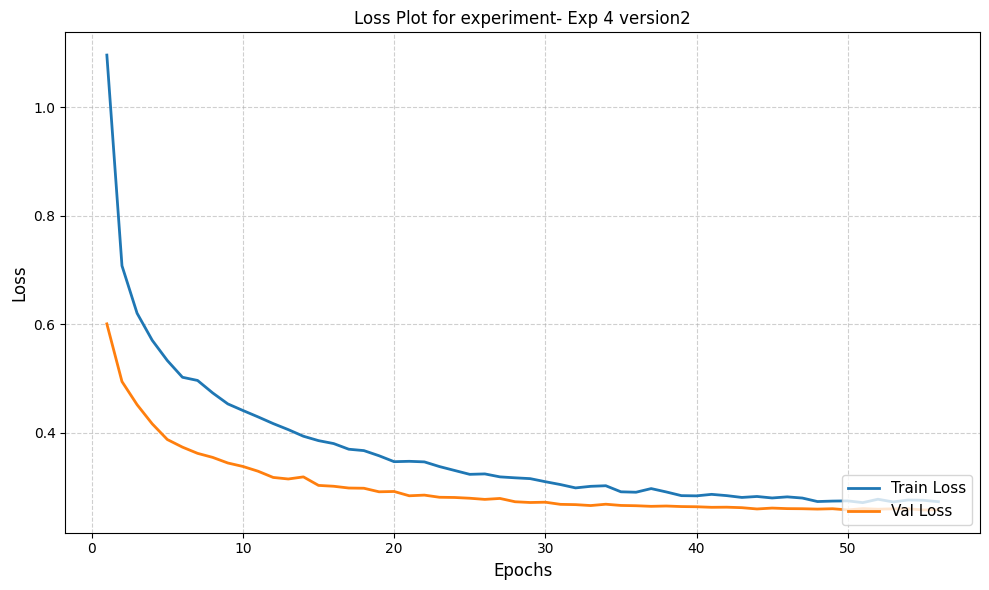

Loss plot has been plotted


Train Loss for Exp 4 version2: 0.27
Val Loss for Exp 4 version2: 0.26


In [20]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment4_v2_prepared_csv["epoch"],
    experiment_name="Exp 4 version2",
    baseline=False,
    main_model_history=experiment4_v2_prepared_csv
)

## Exp5 V1 -- Exp4 V2+Cutmix/Mixup

#### In Exp5 V1 I trained the setup from Exp4 V2 but added CutMix and Mixup, without unfreezing layer3. I set it for 60 epochs but early stopping stopped it at 39. The final results were train accuracy 81% and validation accuracy 89%. The validation looked good, but the training side didn’t adapt well — that’s something that can happen when using CutMix/Mixup since the mixed labels make training harder to fit cleanly.

#### Because of that gap, I moved to Exp5 V2 where I unfroze layer3 and gave it a smaller learning rate (2e‑4). That way the model had more capacity to adapt mid‑level features while still keeping updates stable.

## Exp5 V2 ----- with standard augmentation + Consine Annealing + Cutmix and Mixup + unfreezing layer3 (lr=2e-4)+layer4(lr=3e-4)+ fc(lr=3e-3)

In [ ]:
exp5_v2_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp5")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp5/metrics_exp5_v2.csv']


In [ ]:
#extract and preprare the csv experiment5 version 2 dataframe to dictionary for easier plotting 
experiment5_v2_prepared_csv=extract_dataframe(df=exp5_v2_csv)

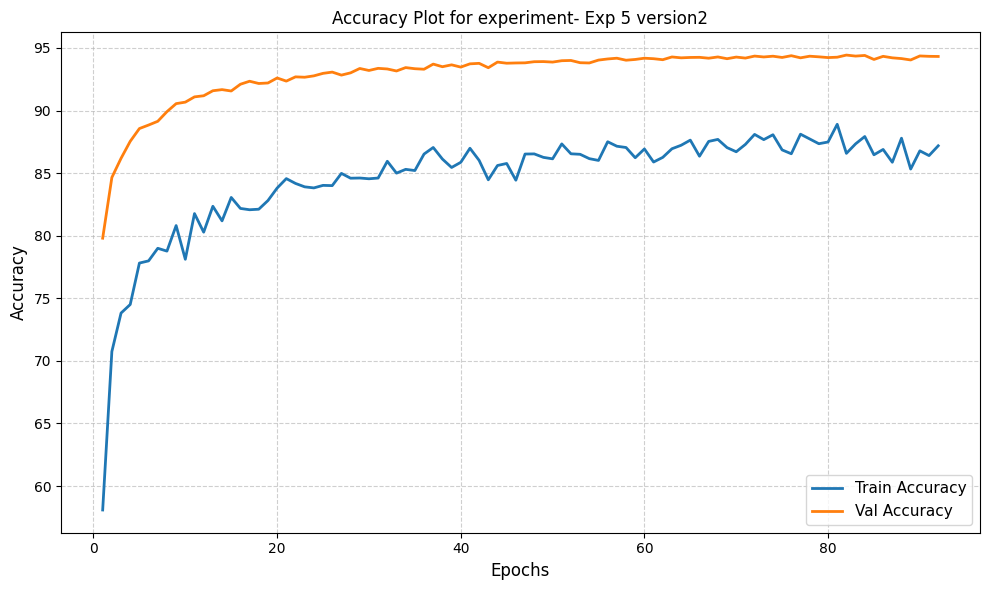

Accuracy plot has been plotted


Train Accuracy for Exp 5 version2: 88.90
Val Accuracy for Exp 5 version2: 94.43


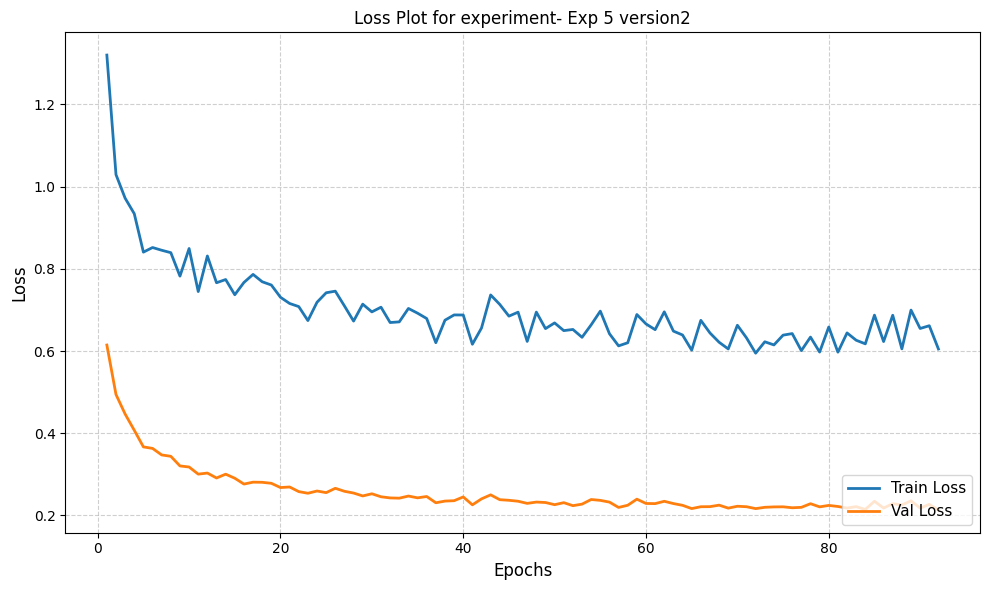

Loss plot has been plotted


Train Loss for Exp 5 version2: 0.59
Val Loss for Exp 5 version2: 0.21


In [ ]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment5_v2_prepared_csv["epoch"],
    experiment_name="Exp 5 version2",
    baseline=False,
    main_model_history=experiment5_v2_prepared_csv
)

## Experiment 5 Model --- V3 (layers=(layer3,layer4,fc), learning rates=[2e-4,3e-4,3e-3]) + adding random Erasing augmentation + adding cosine annealing warmstart (replaced standard cosine annealing) 

In [12]:
exp5_v3_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp5_v3")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp5_v3/metrics_exp5_v3_1.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp5_v3/metrics_exp5_v3_2.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp5_v3/metrics_exp5_v3_3.csv']


In [14]:
#extract and preprare the csv experiment5 version 3 dataframe to dictionary for easier plotting 
experiment5_v3_prepared_csv=extract_dataframe(df=exp5_v3_csv)

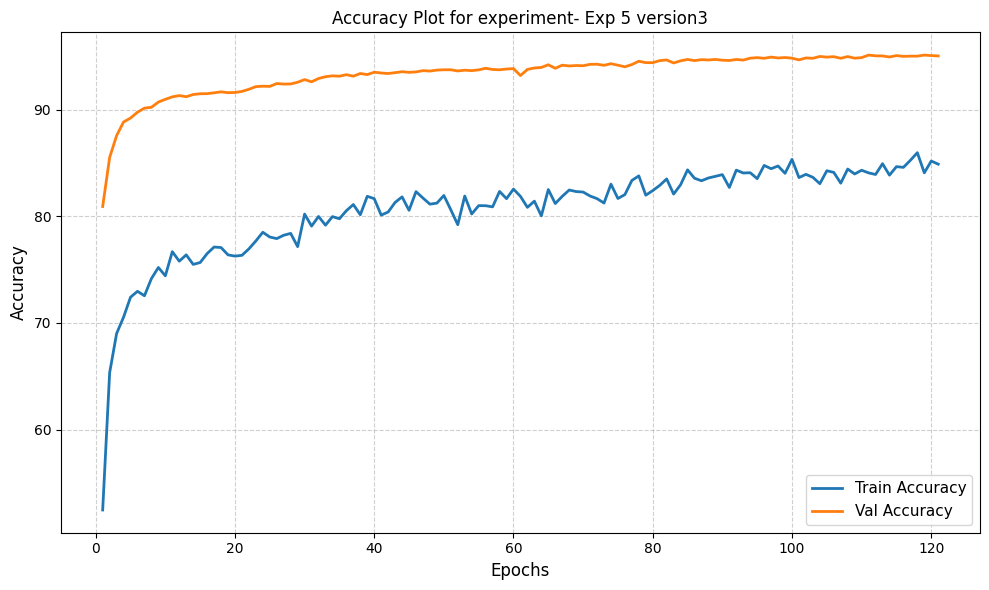

Accuracy plot has been plotted


Train Accuracy for Exp 5 version3: 85.98
Val Accuracy for Exp 5 version3: 95.14


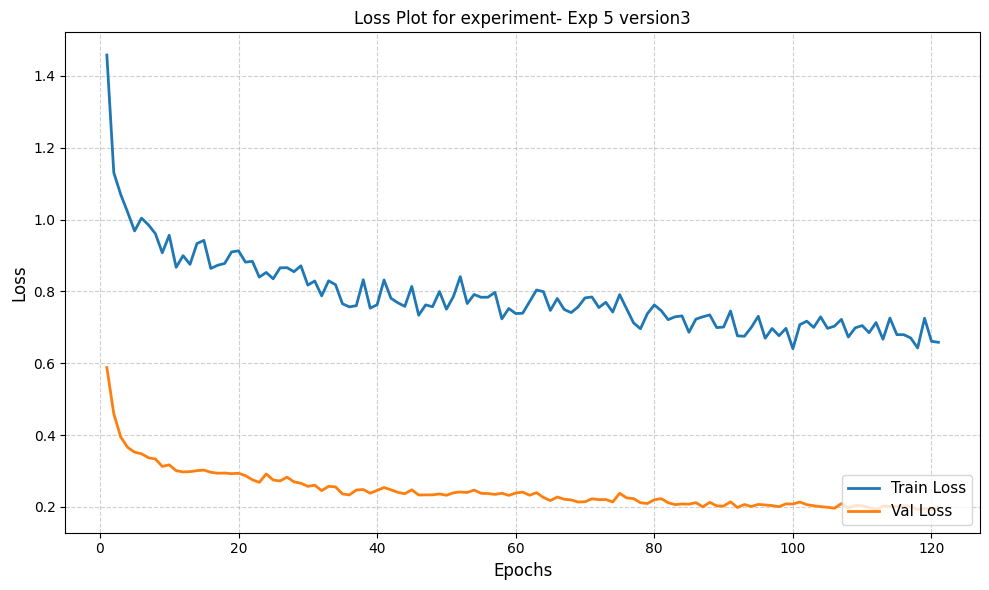

Loss plot has been plotted


Train Loss for Exp 5 version3: 0.64
Val Loss for Exp 5 version3: 0.19


In [15]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment5_v3_prepared_csv["epoch"],
    experiment_name="Exp 5 version3",
    baseline=False,
    main_model_history=experiment5_v3_prepared_csv
)

## test experiment 5 model ---- V2 (layers=[layer3,layer4,fc],learning rates=[2e-4,3e-4,3e-3])

In [21]:
exp5_v2_model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp5_v2",
    num_classes=10,
    device=device
    )

history=test_model(
    model=exp5_v2_model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp5_v2"
        )

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [1.556720744979854e-05, 2.3350811174697777e-05, 0.0002335081117469777]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [22]:
print(history)

{'test_acc': '93.54', 'test_per_class_acc': array([94.2, 96.3, 92.3, 86.6, 92. , 90.1, 97.1, 94.4, 95.7, 96.7],
      dtype=float32), 'test_loss': '0.23', 'conf_matrix': array([[942,   1,   7,   7,   3,   0,   2,   3,  25,  10],
       [  2, 963,   1,   0,   0,   0,   0,   0,   4,  30],
       [ 17,   0, 923,  15,  15,   9,  16,   2,   3,   0],
       [  7,   0,  15, 866,  18,  70,  15,   6,   2,   1],
       [  3,   0,  25,  16, 920,   7,  10,  18,   1,   0],
       [  2,   0,   4,  63,  14, 901,   6,   8,   1,   1],
       [  3,   0,   3,  11,   8,   3, 971,   0,   1,   0],
       [  3,   0,   7,  11,  16,  15,   1, 944,   2,   1],
       [ 24,   5,   1,   3,   1,   0,   1,   2, 957,   6],
       [  4,  19,   1,   2,   0,   0,   0,   0,   7, 967]]), 'precision': array([93.55, 97.47, 93.52, 87.12, 92.46, 89.65, 95.01, 96.03, 95.41,
       95.18], dtype=float32), 'f1score': array([93.87, 96.88, 92.9 , 86.86, 92.23, 89.88, 96.04, 95.21, 95.56,
       95.93], dtype=float32), 'recall': ar

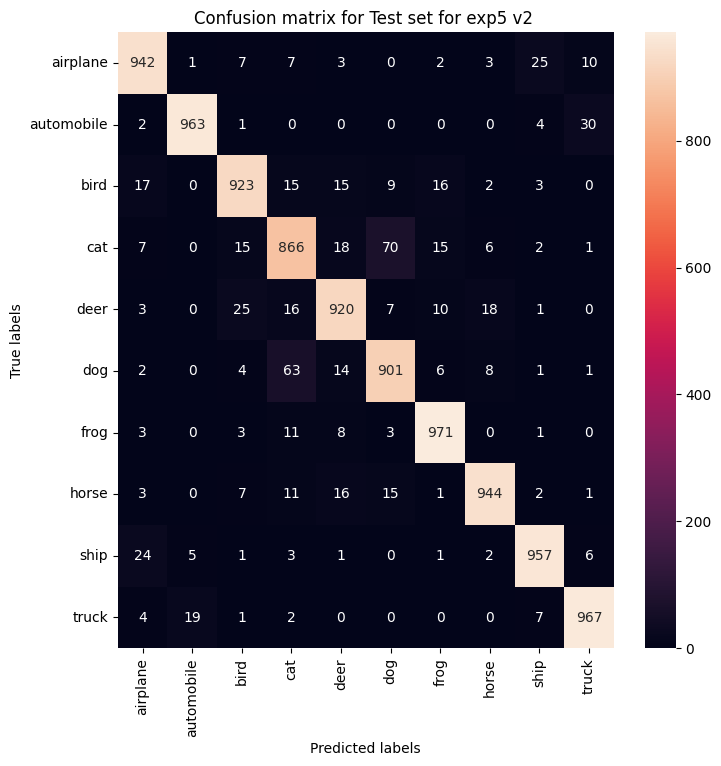

In [23]:
confusion_matrix_plot(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="exp5_v2")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="exp5 v2")

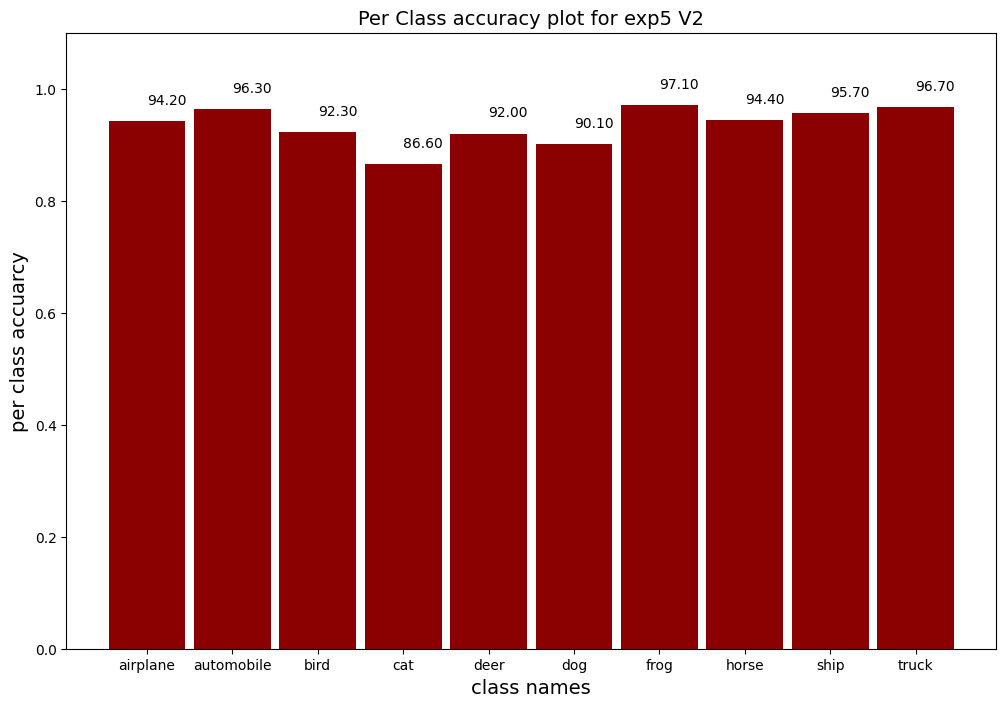

In [24]:
each_class_accuracy(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="exp5_v2")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="exp5 V2")

## Experiment 5 Version3

In [25]:
exp5_v3_model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp5_v3",
    num_classes=10,
    device=device
    )

history=test_model(
    model=exp5_v3_model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp5_v3"
        )

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [5.8843356115025935e-05, 8.791036923815453e-05, 0.000872719723562627]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [26]:
print(history)

{'test_acc': '94.31', 'test_per_class_acc': array([96.2, 97.1, 93.2, 88.1, 93.7, 89.8, 96.8, 95.3, 96.6, 96.3],
      dtype=float32), 'test_loss': '0.21', 'conf_matrix': array([[962,   4,   6,   1,   2,   0,   1,   2,  15,   7],
       [  0, 971,   1,   1,   0,   0,   0,   0,   5,  22],
       [ 17,   0, 932,  16,  12,   8,  11,   0,   4,   0],
       [  6,   2,  12, 881,  15,  59,  13,   7,   3,   2],
       [  2,   0,  14,  12, 937,   8,  10,  17,   0,   0],
       [  2,   0,   5,  68,  15, 898,   3,   6,   2,   1],
       [  4,   0,   5,  13,   6,   3, 968,   1,   0,   0],
       [  4,   0,   8,   6,  12,  14,   1, 953,   1,   1],
       [ 21,   6,   1,   2,   0,   0,   0,   0, 966,   4],
       [  4,  23,   1,   1,   0,   0,   0,   0,   8, 963]]), 'precision': array([94.13, 96.52, 94.62, 88.01, 93.79, 90.71, 96.13, 96.65, 96.22,
       96.3 ], dtype=float32), 'f1score': array([95.15, 96.81, 93.9 , 88.06, 93.75, 90.25, 96.46, 95.97, 96.41,
       96.3 ], dtype=float32), 'recall': ar

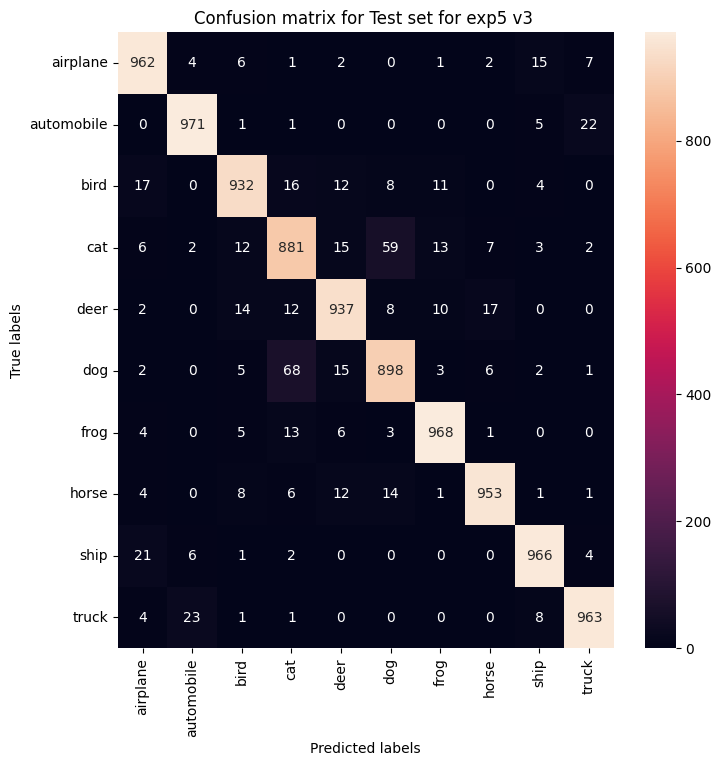

In [27]:
confusion_matrix_plot(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="exp5_v3")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="exp5 v3")

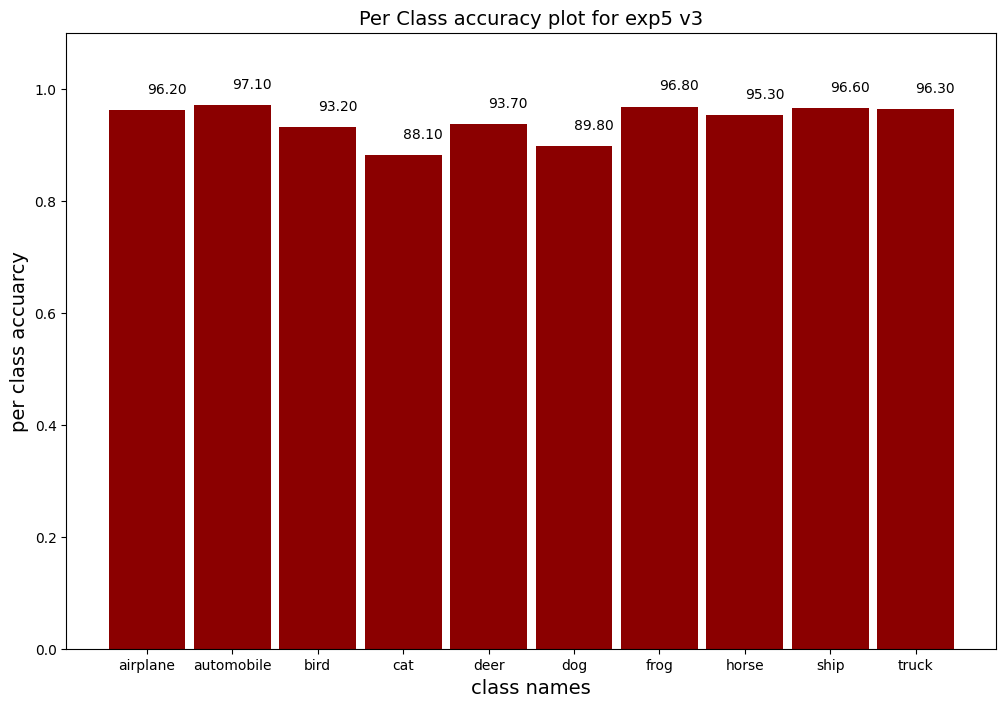

In [28]:
each_class_accuracy(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="exp5_v3")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="exp5 v3")

## test experiment 3 model ------ (layers=[layer4,fc],learning  rates=[1e-4,1e-3]) + just standard augmentation

In [29]:
exp3_model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp3",
    num_classes=10,
    device=device
    )

history=test_model(
    model=exp3_model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp3"
        )

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [0.0001, 0.001]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [30]:
print(history)

{'test_acc': '89.43', 'test_per_class_acc': array([92.2, 92.5, 87.9, 75. , 88.8, 86.4, 93.1, 90.5, 93.4, 94.5],
      dtype=float32), 'test_loss': '0.31', 'conf_matrix': array([[922,   3,  14,   8,   4,   0,   1,   5,  30,  13],
       [  9, 925,   1,   2,   0,   0,   1,   1,  12,  49],
       [ 22,   0, 879,  21,  31,  18,  16,   9,   2,   2],
       [ 12,   2,  35, 750,  26, 118,  31,  13,   6,   7],
       [  5,   0,  30,  18, 888,  14,  15,  28,   2,   0],
       [  3,   0,  13,  80,  20, 864,   9,  11,   0,   0],
       [  5,   1,  15,  15,  19,  11, 931,   1,   2,   0],
       [ 11,   1,  12,   8,  38,  17,   3, 905,   1,   4],
       [ 39,   7,   7,   2,   2,   0,   1,   0, 934,   8],
       [  8,  32,   1,   0,   0,   0,   1,   1,  12, 945]]), 'precision': array([89.  , 95.26, 87.29, 82.96, 86.38, 82.92, 92.27, 92.92, 93.31,
       91.93], dtype=float32), 'f1score': array([90.57, 93.86, 87.59, 78.78, 87.57, 84.62, 92.68, 91.69, 93.35,
       93.2 ], dtype=float32), 'recall': ar

## Experiment 2 ---- (layers=[layer4,fc],learning rates=[1e-4,1e-3]) Note: just unfreezing layer4 and fc

In [31]:
exp2_model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp2",
    num_classes=10,
    device=device
    )

history=test_model(
    model=exp2_model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp2"
        )
print (history)

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [0.0001, 0.001]


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

{'test_acc': '87.46', 'test_per_class_acc': array([87.7, 93.1, 85.7, 74.1, 84.7, 83.1, 92.2, 89.2, 93.3, 91.5],
      dtype=float32), 'test_loss': '0.37', 'conf_matrix': array([[877,   3,  21,  14,   6,   1,   5,   4,  55,  14],
       [  9, 931,   0,   1,   0,   1,   3,   3,  13,  39],
       [ 14,   0, 857,  38,  33,  14,  24,  14,   4,   2],
       [  6,   3,  29, 741,  26, 118,  38,  23,  13,   3],
       [ 10,   1,  31,  24, 847,  18,  27,  37,   4,   1],
       [  1,   0,  14, 107,  18, 831,   9,  20,   0,   0],
       [  5,   1,  20,  21,  15,  11, 922,   2,   3,   0],
       [  7,   0,  14,  17,  31,  26,   6, 892,   1,   6],
       [ 34,  10,   6,   4,   1,   0,   2,   1, 933,   9],
       [ 19,  45,   1,   7,   0,   0,   2,   0,  11, 915]]), 'precision': array([89.31, 93.66, 86.3 , 76.08, 86.69, 81.47, 88.82, 89.56, 89.97,
       92.52], dtype=float32), 'f1score': array([88.5 , 93.38, 86.  , 75.08, 85.69, 82.28, 90.48, 89.38, 91.61,
       92.01], dtype=float32), 'recall': ar

## Baseline test result --- (layers=[fc], learning rates=[1e-3])

In [32]:
baseline_model=load_model_for_test(
    is_baseline=True,
    model_dir=csv_file_path,
    experiment_name="baseline",
    num_classes=10,
    device=device
    )

history=test_model(
    model=baseline_model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/baseline"
        )

change the head of resnet18 to 10


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [50]:
print(history)

{'test_acc': '79.26', 'test_per_class_acc': array([81.7, 88.1, 73.9, 63.8, 74.6, 75. , 82.4, 82.1, 84.3, 86.7],
      dtype=float32), 'test_loss': '0.62', 'conf_matrix': array([[817,  10,  41,   8,   5,   2,   6,  20,  67,  24],
       [ 22, 881,   4,   5,   0,   2,   3,   9,  14,  60],
       [ 46,   4, 739,  40,  61,  25,  45,  21,  14,   5],
       [ 21,   5,  49, 638,  35, 147,  55,  27,  12,  11],
       [ 14,   2,  58,  31, 746,  16,  33,  87,   9,   4],
       [  4,   1,  34, 108,  27, 750,  19,  52,   3,   2],
       [  6,   5,  48,  37,  39,  25, 824,   8,   5,   3],
       [ 14,   5,  26,  21,  49,  33,  13, 821,   9,   9],
       [ 79,  27,  13,   8,   1,   5,   3,   3, 843,  18],
       [ 23,  63,   2,   7,   1,   5,   2,   5,  25, 867]]), 'precision': array([78.11, 87.84, 72.88, 70.65, 77.39, 74.26, 82.15, 77.97, 84.22,
       86.44], dtype=float32), 'f1score': array([79.86, 87.97, 73.39, 67.05, 75.97, 74.63, 82.28, 79.98, 84.26,
       86.57], dtype=float32), 'recall': ar

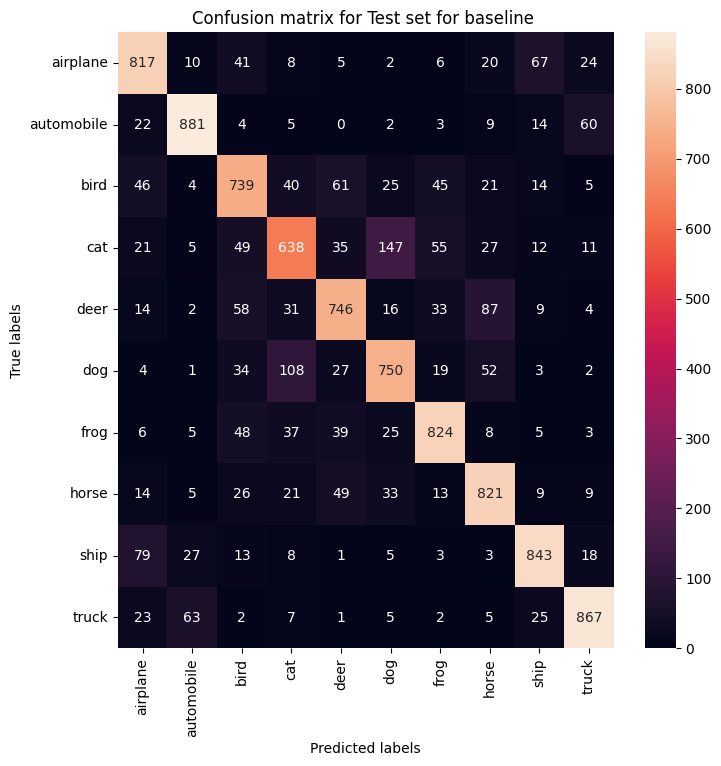

In [34]:
confusion_matrix_plot(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="baseline")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="baseline")

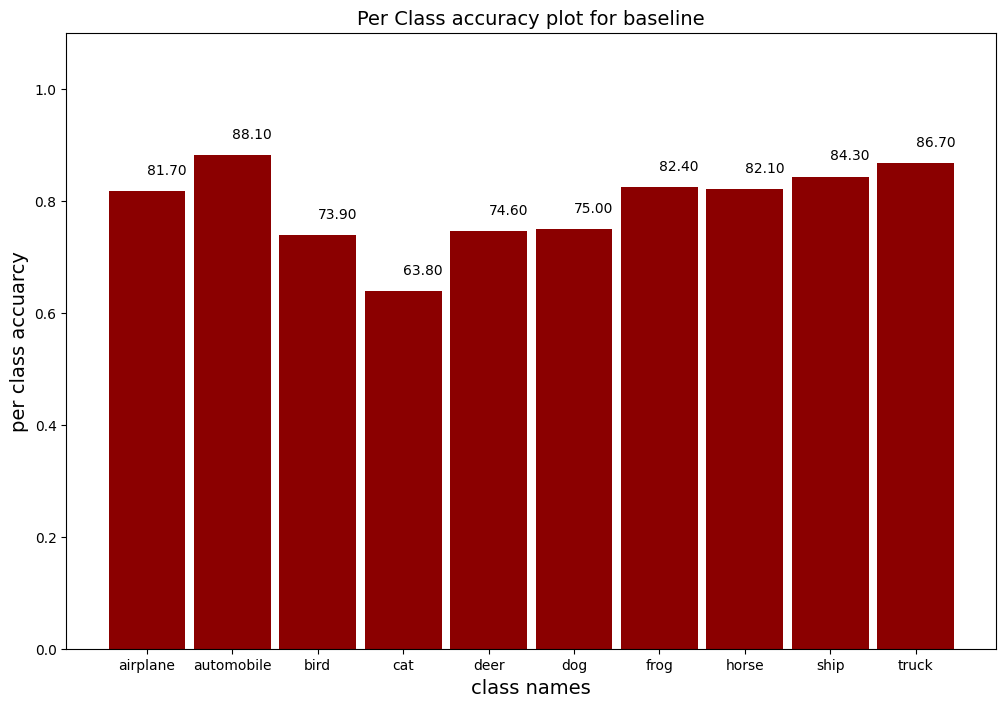

In [35]:
each_class_accuracy(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="baseline")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="baseline")

In [36]:
def models_collection_helper_function(model_names:List):
    
    "models collective helper"
    models={}
    for name in model_names:
        
        models[name]=load_model_for_test(
            is_baseline=(name=="baseline"), #be aware of it, If set true, all three models will be loaded identical baseline model
            model_dir=csv_file_path,
            experiment_name=name,
            num_classes=10,
            device=device
            )
        
    return models



In [38]:
models_collection=["baseline","exp5_v2","exp5_v3"] #these are the folders where model weights were saved 

In [39]:
models_dict=models_collection_helper_function(model_names=models_collection)

change the head of resnet18 to 10
change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [1.556720744979854e-05, 2.3350811174697777e-05, 0.0002335081117469777]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5


change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [5.8843356115025935e-05, 8.791036923815453e-05, 0.000872719723562627]


In [40]:
calibrated_results=calibrate_eval_model(
    models=models_dict,
    val_dataset=val_dataset,
    batch_size=128,
    device=device,
    split_size=5000,
    bins_size=15,
    initial_T=1.5
    )


Model baseline Calibration in process:   0%|          | 0/40 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2922: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(


Model exp5_v2 Calibration in process:   0%|          | 0/40 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2922: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(


Model exp5_v3 Calibration in process:   0%|          | 0/40 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2922: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(


In [41]:
print(calibrated_results)

[{'model_name': 'baseline', 'before_temperature_log_loss': 0.5780926467244499, 'before_temperature_nll': 0.5780926942825317, 'before_temperature_ece': 0.05545053238272666, 'before_temperature_bin_conf': [0.19448522, 0.24423558, 0.302059, 0.36831632, 0.43229526, 0.50020456, 0.5667433, 0.6328923, 0.70181656, 0.76628315, 0.83439946, 0.9029272, 0.9743385], 'before_temperature_bin_acc': [0.0, 0.24444444444444444, 0.37383177570093457, 0.3902439024390244, 0.4882154882154882, 0.5809248554913294, 0.6563467492260062, 0.6997167138810199, 0.7959183673469388, 0.8553299492385786, 0.9246861924686193, 0.9502262443438914, 0.9921652421652422], 'after_temperature_log_loss': 0.5591453947579421, 'after_temperature_nll': 0.5591453909873962, 'after_temperature_ece': 0.012294163614511498, 'after_temperature_bin_conf': [0.24558413, 0.301293, 0.37238094, 0.43441933, 0.5011083, 0.56597376, 0.63326204, 0.69928885, 0.7684138, 0.8344959, 0.90178746, 0.97858566], 'after_temperature_bin_acc': [0.15789473684210525, 0.

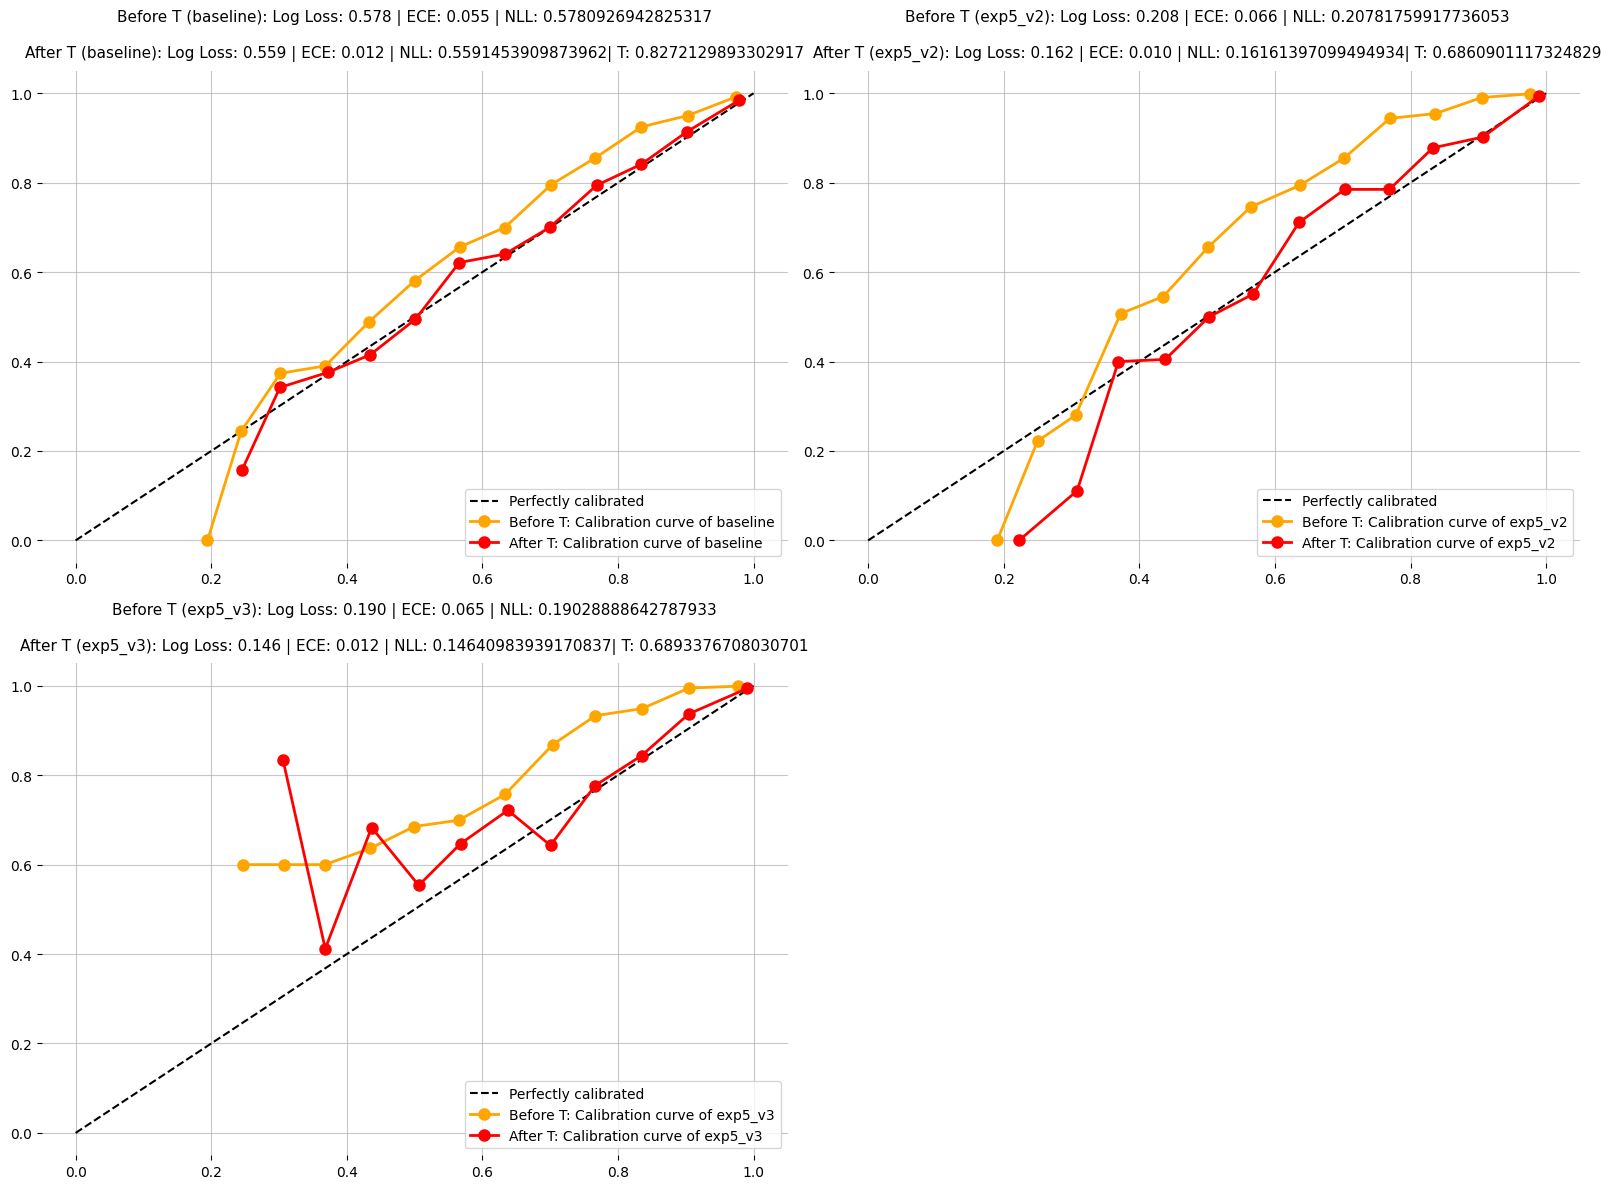

In [42]:
visualize_reliability_diagram(calibrated_result=calibrated_results,model_names=models_collection,row_expand=8,col_expand=6)


### Get the models history files which are saved each test of (baseline,exp5 version 2, exp5 version 3) 

In [51]:
baseline_history=get_test_history_dict(dict_path="./result",experiment_name="baseline")
exp5_v2_history=get_test_history_dict(dict_path="./result",experiment_name="exp5_v2")
exp5_v3_history=get_test_history_dict(dict_path="./result",experiment_name="exp5_v3")


### Exp5 V3 (F1 Score/Precision/ F1 Score) w.r.t per class

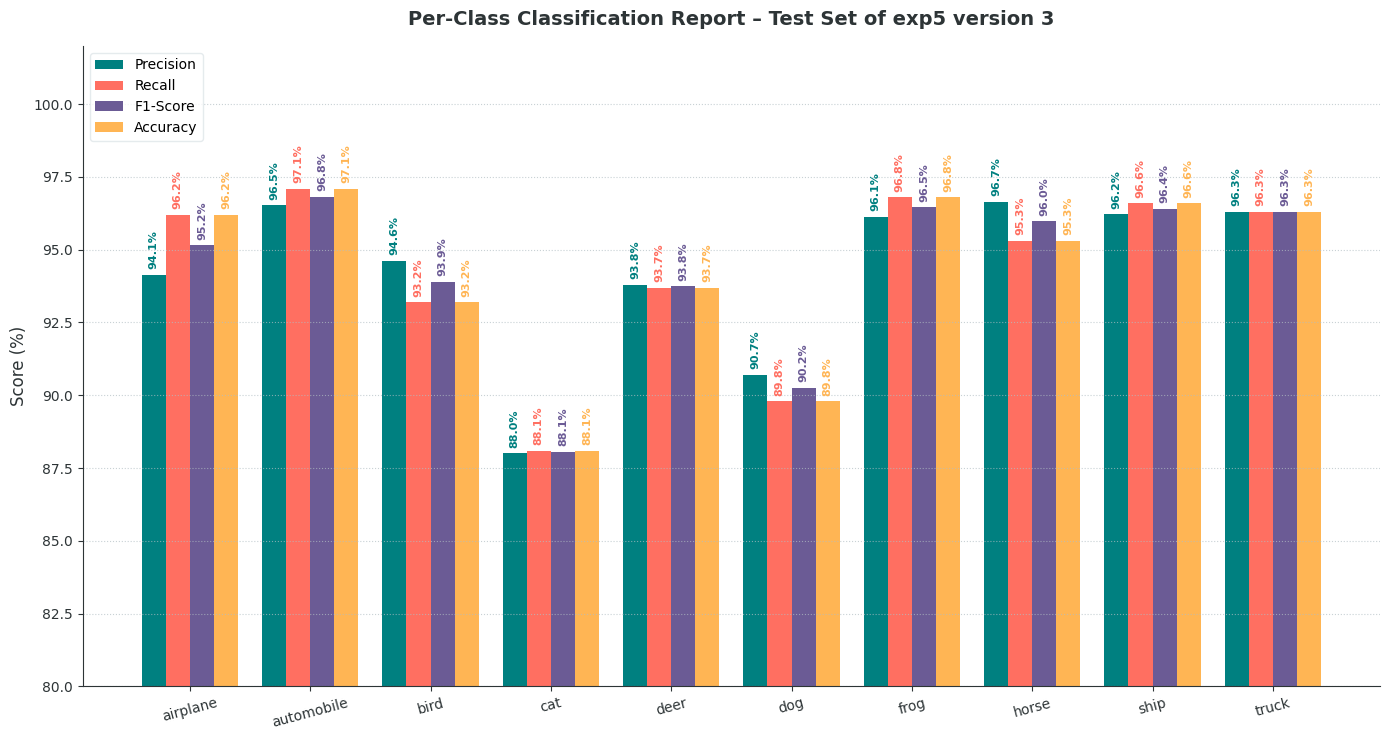

In [52]:
visualize_per_class_classification_report(
    precision=exp5_v3_history["precision"],
    recall=exp5_v3_history["recall"],
    f1_score=exp5_v3_history["f1score"],
    accuracy=exp5_v3_history["test_per_class_acc"],
    dataset_classes=cifar10_classes,
    experiment_name="exp5 version 3")


### Exp5 V2 (F1 Score/Precision/ F1 Score) w.r.t per class

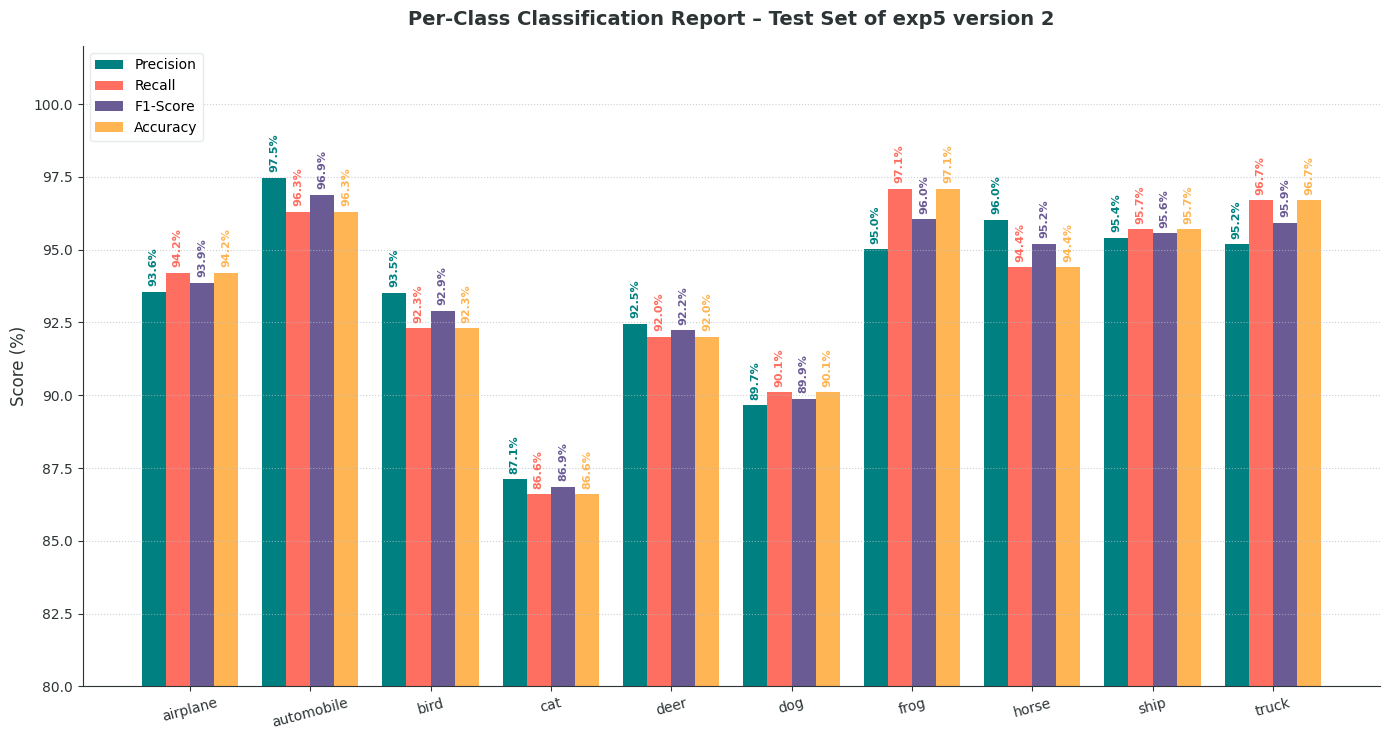

In [54]:
visualize_per_class_classification_report(
    precision=exp5_v2_history["precision"],
    recall=exp5_v2_history["recall"],
    f1_score=exp5_v2_history["f1score"],
    accuracy=exp5_v2_history["test_per_class_acc"],
    dataset_classes=cifar10_classes,
    experiment_name="exp5 version 2")


### Baseline (F1 Score/Precision/ F1 Score) w.r.t per class

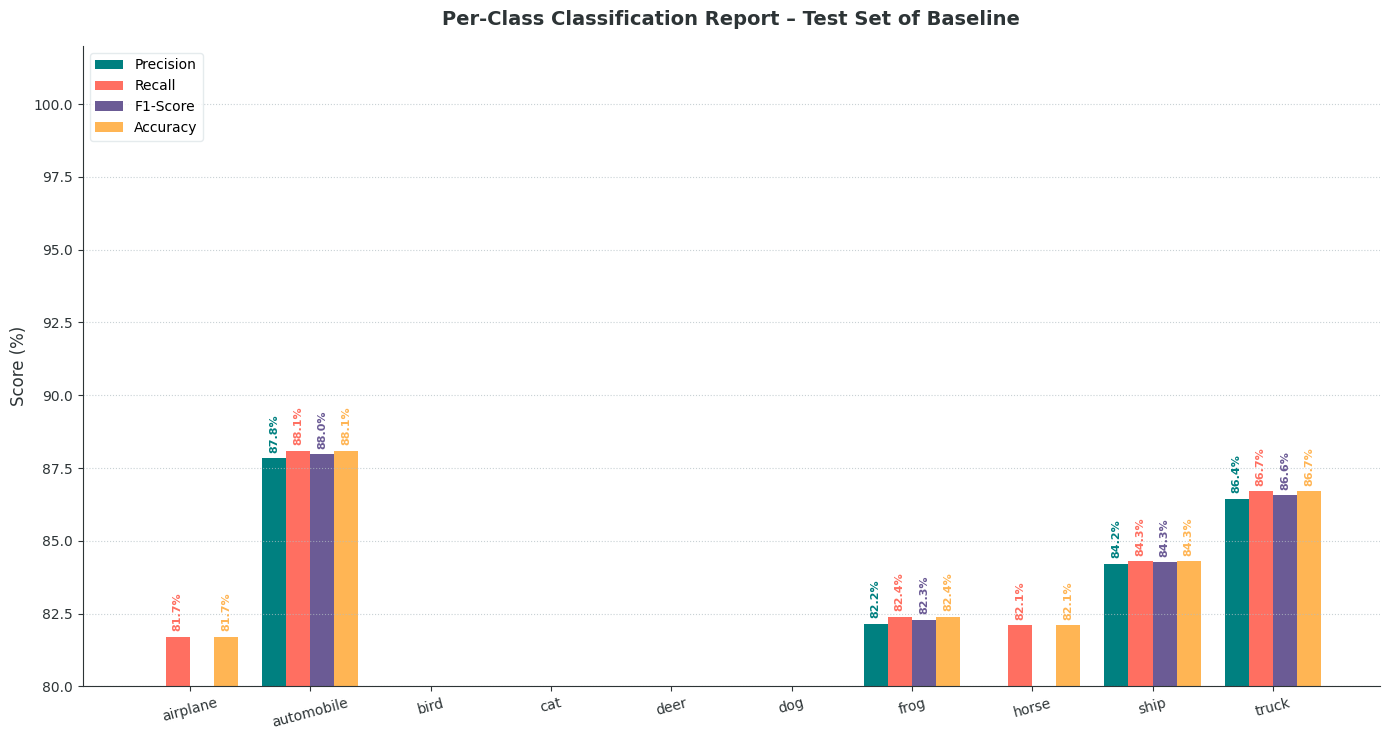

In [55]:
visualize_per_class_classification_report(
    precision=baseline_history["precision"],
    recall=baseline_history["recall"],
    f1_score=baseline_history["f1score"],
    accuracy=baseline_history["test_per_class_acc"],
    dataset_classes=cifar10_classes,
    experiment_name="Baseline")
